# What Determines Airbnb Prices in Buenos Aires?

**Analysis by:** Margionet
**Tools:** Python (pandas, matplotlib)
**Data source:** [Inside Airbnb](http://insideairbnb.com/) — detailed listings for Buenos Aires

## Objective

This notebook explores which factors are associated with nightly price differences
across Airbnb listings in Buenos Aires: location (neighbourhood), room type, and
guest capacity. Along the way, it also demonstrates a common data-cleaning pitfall
(mixing categories before comparing groups) and how to correct for it.


## 1. Import libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None) 


## 2. Load data

The dataset contains 90 columns describing each listing (price, location, host
info, reviews, amenities, etc.). We start by loading it and taking a first look.


In [2]:
df = pd.read_csv("listings.csv", low_memory=False)
print("Shape:", df.shape)
df[["price", "property_type", "room_type", "neighbourhood_cleansed",
    "accommodates", "bedrooms", "bathrooms"]].head()


Shape: (29609, 90)


,price,property_type,room_type,neighbourhood_cleansed,accommodates,bedrooms,bathrooms
0,"$185,388.00",Entire condo,Entire home/apt,Palermo,2,1.0,1.0
1,"$101,945.00",Entire condo,Entire home/apt,Belgrano,2,1.0,1.0
2,NaN,Entire rental unit,Entire home/apt,Palermo,2,1.0,NaN
3,"$235,938.03",Entire rental unit,Entire home/apt,Palermo,4,2.0,1.5
4,"$113,841.00",Entire rental unit,Entire home/apt,San Nicolas,3,1.0,1.0


## 3. Data cleaning

### 3.1 Convert `price` to a number

The `price` column is stored as text, e.g. `"$185,388.00"`. We remove the currency
symbol and thousands separators, then convert it to a numeric type.

We also drop rows with a missing price (about 6.5% of the data) — without a price,
those listings can't be used in this analysis.


In [3]:
print("Rows before dropping missing price:", len(df))

df = df.dropna(subset=["price"])
df["price"] = df["price"].str.replace("$", "", regex=False)
df["price"] = df["price"].str.replace(",", "", regex=False)
df["price"] = df["price"].astype(float)

print("Rows after dropping missing price:", len(df))
df["price"].describe()


Rows before dropping missing price: 29609
Rows after dropping missing price: 27691


count    2.769100e+04
mean     2.884595e+05
std      3.651413e+06
min      1.215500e+03
25%      7.731100e+04
50%      1.036420e+05
75%      1.465205e+05
max      1.741133e+08
Name: price, dtype: float64

### 3.2 Removing extreme outliers

The raw price distribution is heavily distorted by a small number of clearly
erroneous values — for example, a 2-guest apartment listed at over 174,000,000
ARS per night. These are almost certainly data entry errors, not real prices.

Looking at percentiles, there's a massive jump between the 99th percentile
(~930,000 ARS) and the 99.9th percentile (~69,000,000 ARS) — a 74x jump. This
confirms the top ~0.1% of values are broken, not a genuine long tail of luxury
listings.

**Decision:** we cap the data at the 99th percentile, removing the most extreme
1% of listings while keeping legitimately expensive properties.


In [4]:
price_cap = df["price"].quantile(0.99)
print(f"99th percentile price cap: {price_cap:,.0f} ARS")

rows_before = len(df)
df = df[df["price"] <= price_cap]
print(f"Rows removed as outliers: {rows_before - len(df)} ({(rows_before - len(df))/rows_before*100:.1f}%)")
print(f"Rows remaining: {len(df)}")


99th percentile price cap: 930,560 ARS
Rows removed as outliers: 276 (1.0%)
Rows remaining: 27415


## 4. Exploratory Data Analysis (EDA)

### 4.1 Price distribution

After removing outliers, the price distribution shows the typical shape for price
data: a peak around 50,000–150,000 ARS, with a long right tail of pricier listings.


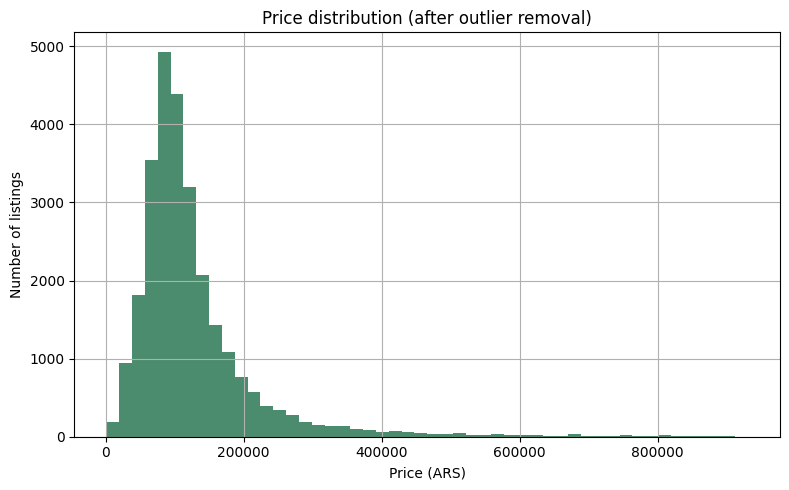

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
df["price"].hist(bins=50, ax=ax, color="#4C8C6E")
ax.set_title("Price distribution (after outlier removal)")
ax.set_xlabel("Price (ARS)")
ax.set_ylabel("Number of listings")
plt.tight_layout()
plt.show()


### 4.2 Where are most listings located?

There are 48 distinct neighbourhoods in the dataset. Palermo stands out with
nearly 9,000 listings — more than double the second-place neighbourhood.


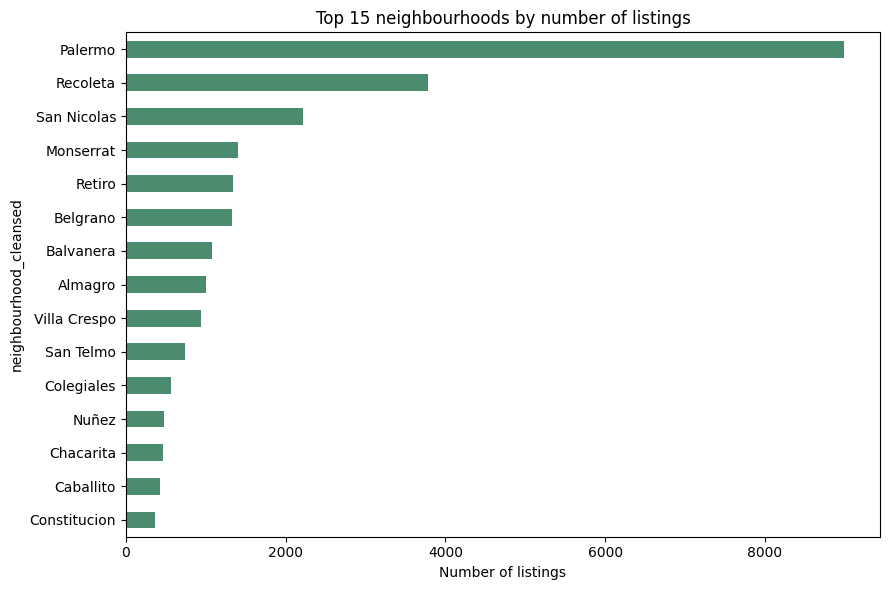

In [6]:
top_neighbourhoods = df["neighbourhood_cleansed"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top_neighbourhoods.sort_values().plot(kind="barh", ax=ax, color="#4C8C6E")
ax.set_title("Top 15 neighbourhoods by number of listings")
ax.set_xlabel("Number of listings")
plt.tight_layout()
plt.show()


## 5. What drives the price?

### 5.1 Price by neighbourhood

A natural first question: does a more popular neighbourhood also mean a higher
price? We compare the median price across the top 15 neighbourhoods.


neighbourhood_cleansed
Colegiales      115847.0
Palermo         114645.0
Belgrano        110216.0
Recoleta        109651.0
Nuñez           107685.0
Retiro          105007.0
San Nicolas      94723.0
San Telmo        93074.0
Chacarita        90823.0
Villa Crespo     89552.0
Monserrat        89269.0
Almagro          84868.0
Constitucion     84123.0
Balvanera        83259.0
Caballito        81890.0
Name: price, dtype: float64


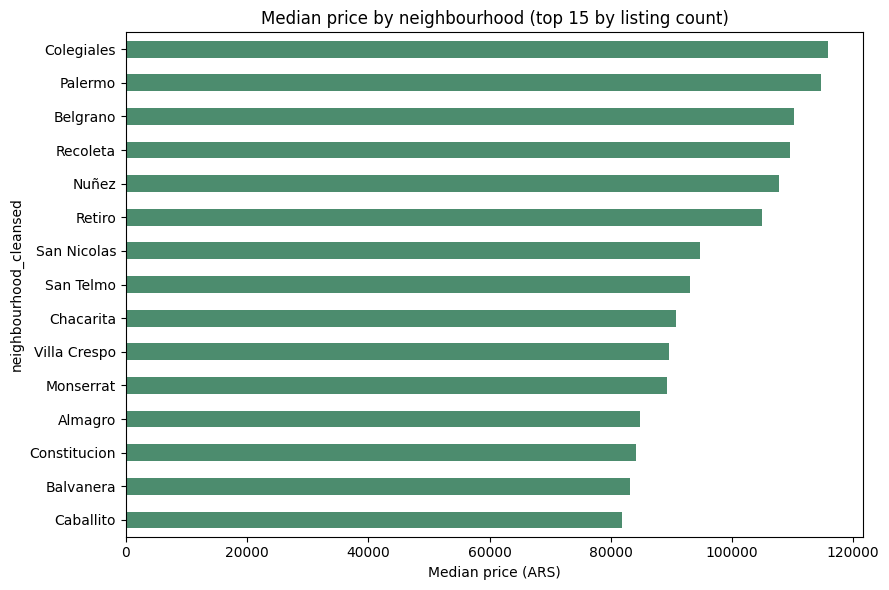

In [7]:
top15 = df["neighbourhood_cleansed"].value_counts().head(15).index
df_top15 = df[df["neighbourhood_cleansed"].isin(top15)]

price_by_neighbourhood = (
    df_top15.groupby("neighbourhood_cleansed")["price"]
    .median()
    .sort_values(ascending=False)
)
print(price_by_neighbourhood.round(0))

fig, ax = plt.subplots(figsize=(9, 6))
price_by_neighbourhood.sort_values().plot(kind="barh", ax=ax, color="#4C8C6E")
ax.set_title("Median price by neighbourhood (top 15 by listing count)")
ax.set_xlabel("Median price (ARS)")
plt.tight_layout()
plt.show()


**First impression:** Palermo — by far the most popular neighbourhood — is only
the *second* most expensive, behind Colegiales (which has far fewer listings).

A plausible explanation: Palermo's popularity as a touristic, attractive area
drives strong supply as well as demand. With nearly 9,000 competing listings,
hosts face more pressure to keep prices competitive, which moderates the median
price despite high demand.

**However, this comparison mixes very different listing types** (entire homes,
private rooms, shared rooms) into a single neighbourhood average — see the next
section for why that matters.


### 5.2 Price by room type

Room type has a much stronger and more direct effect on price than neighbourhood.


                   median      mean  count
room_type                                 
Hotel room       234025.0  236197.0    127
Entire home/apt  107200.0  132509.0  24717
Private room      51835.0   75019.0   2435
Shared room       28408.0   36963.0    136


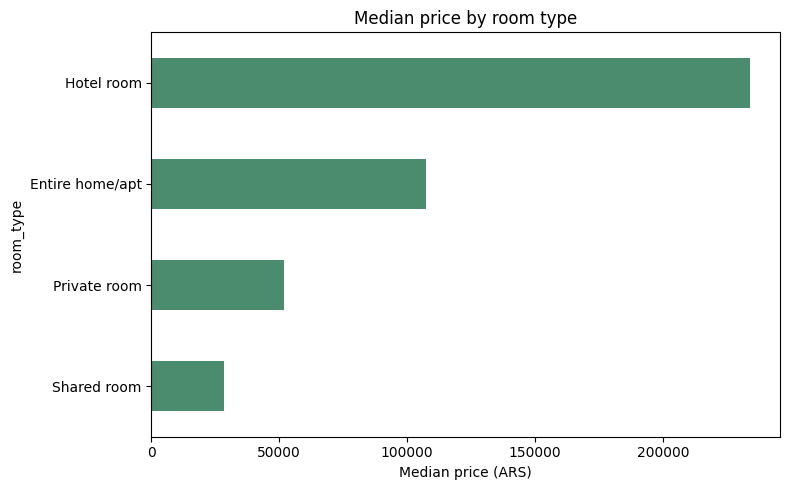

In [8]:
price_by_room = (
    df.groupby("room_type")["price"]
    .agg(["median", "mean", "count"])
    .sort_values("median", ascending=False)
)
print(price_by_room.round(0))

fig, ax = plt.subplots(figsize=(8, 5))
price_by_room["median"].sort_values().plot(kind="barh", ax=ax, color="#4C8C6E")
ax.set_title("Median price by room type")
ax.set_xlabel("Median price (ARS)")
plt.tight_layout()
plt.show()


Entire homes/apartments (90% of all listings) go for roughly double the price of
a private room, and about 4x a shared room — an intuitive, consistent pattern:
the more exclusive the space, the higher the price.


### 5.3 Price by guest capacity (`accommodates`)

This shows the cleanest, most consistent relationship of all: price rises almost
monotonically with the number of guests a listing can host.


                median      mean  count
accommodates                           
1              42118.0   54141.0   1310
2              91573.0  104643.0  13329
3             104075.0  120446.0   4772
4             127301.0  149341.0   5532
5             170457.0  197425.0   1046
6             206535.0  243259.0    844
7             246566.0  281560.0    156
8             277553.0  326650.0    192
9             336267.0  350667.0     44
10            430090.0  422755.0     62
11            452021.0  466231.0     16
12            545531.0  524675.0     31
13            509858.0  521582.0      4
14            523782.0  473642.0     11
15            503708.0  400631.0     13
16            551006.0  564993.0     53


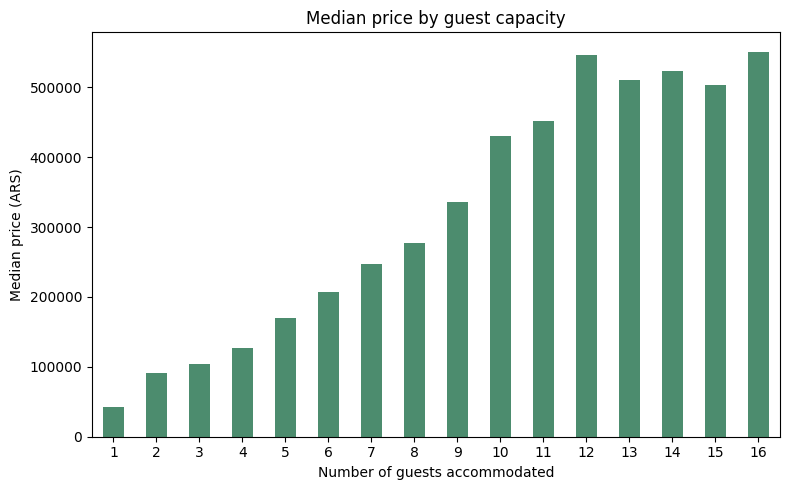

In [9]:
price_by_capacity = df.groupby("accommodates")["price"].agg(["median", "mean", "count"])
print(price_by_capacity.round(0))

fig, ax = plt.subplots(figsize=(8, 5))
price_by_capacity["median"].plot(kind="bar", ax=ax, color="#4C8C6E")
ax.set_title("Median price by guest capacity")
ax.set_xlabel("Number of guests accommodated")
ax.set_ylabel("Median price (ARS)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Note that for capacities of 12+ guests, the sample size drops sharply (as low as
4 listings), so those medians are less statistically reliable and shouldn't be
over-interpreted.


## 6. Correcting a bias: neighbourhood price, controlling for room type

Section 5.1 compared neighbourhoods using *all* room types mixed together. Since
Palermo has proportionally more lower-priced private/shared rooms in its listing
mix, its overall median was pulled down relative to neighbourhoods with a
different mix.

To make a fair comparison, we now restrict the analysis to **entire homes/apartments
only**, and compare neighbourhoods on that single, consistent category.


neighbourhood_cleansed
Palermo        117127.0
Belgrano       112015.0
Recoleta       110917.0
Retiro         104779.0
San Nicolas     97085.0
Monserrat       95289.0
Balvanera       90469.0
Almagro         88917.0
Name: price, dtype: float64


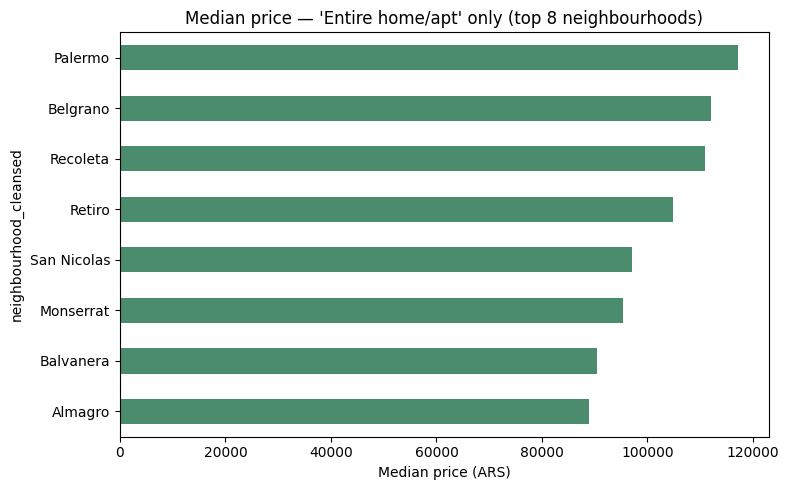

In [10]:
top8 = df["neighbourhood_cleansed"].value_counts().head(8).index
df_entire = df[
    df["neighbourhood_cleansed"].isin(top8) & (df["room_type"] == "Entire home/apt")
]

price_entire_by_neighbourhood = (
    df_entire.groupby("neighbourhood_cleansed")["price"]
    .median()
    .sort_values(ascending=False)
)
print(price_entire_by_neighbourhood.round(0))

fig, ax = plt.subplots(figsize=(8, 5))
price_entire_by_neighbourhood.sort_values().plot(kind="barh", ax=ax, color="#4C8C6E")
ax.set_title("Median price — 'Entire home/apt' only (top 8 neighbourhoods)")
ax.set_xlabel("Median price (ARS)")
plt.tight_layout()
plt.show()


**Corrected result:** once we compare like-for-like (entire homes only), Palermo
*is* the most expensive of the top neighbourhoods — consistent with it being the
most in-demand, touristic area.

This is a useful lesson: comparing raw group averages without controlling for a
confounding variable (room type mix, in this case) can produce a misleading
conclusion. The initial "Palermo is surprisingly affordable" reading was an
artifact of mixing listing types, not a genuine pricing pattern.


## 7. Conclusions

- **Guest capacity** is the strongest and most consistent price driver: price
  rises steadily from ~42,000 ARS (1 guest) to ~550,000 ARS (16 guests).
- **Room type** has a large, intuitive effect: entire homes cost roughly 2x a
  private room and 4x a shared room.
- **Neighbourhood** matters, but only becomes clearly visible once room type is
  held constant. Palermo — the most popular and touristic neighbourhood — is the
  most expensive among top neighbourhoods when comparing entire homes only, even
  though its overall (mixed-category) median looked more moderate due to its
  large and varied supply.
- **Data quality matters**: a small fraction (~1%) of listings had clearly
  erroneous prices (up to 174 million ARS/night for a 2-guest apartment) that
  would have severely distorted any analysis if left unfiltered.
